# Dataset Distributions

This notebook investigates the distributions of key political identity-building categories related to political actors, based on dataset metadata - with a focus on sentiment-related trends of membership and group relation categories.  

### Categories of Interest
- **Membership**: Political parties, parliamentary groups, ministers  
- *Ideology*: Party families, GAL–TAN positionings (CHES variables)  
- **Group Relations**: Party status (Coalition vs. Opposition), political orientation (LRGEN, Wikipedia classifications)  

### Purpose

The goal of this exploration is to:
1. *Investigate basic distributions* to gain an overview of the dataset’s structure  
2. *Identify trends* within the political landscape of the studied parliamentary period  

### Focus Areas
- *Party activity*: How political parties and groups are distributed and represented  
- *Sentiment trends*: Patterns in sentiment across different ideological or group categories  

--- 

Sample input: 
Pre-processed dataset [ParlaMint-SI_5.1_master.tsv](../Sample/Datasets/ParlaMint-SI_5.1_master.tsv) 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #Sample input
df =  pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #Full dataset input
df.head()

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
0,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u1,Spoštovane kolegice poslanke in kolegi poslanc...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.25,56,986,1149,ZLSD/SD,2013,NaN,NaN,NaN,NaN
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
2,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u3,Hvala tudi vam. Dajem besedo predsednici Vlade...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.00,3,11,15,ZLSD/SD,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
4,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u5,Hvala za odgovor. Gospod Prevc bo predstavil z...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.00,3,12,15,ZLSD/SD,2013,NaN,NaN,NaN,NaN


## Dataset characteristics

Checking basic characteristics of the entire dataset, before omitting procedural and minster speeches.

In [3]:
print(df.shape)
df.describe(include="all")

(311354, 30)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
count,311354,311354,311354,311354,311354,311354,311354,311354,311354,311354,...,311347.000000,311354.000000,311354.000000,311354.000000,311354,311354.000000,68490.000000,68490.000000,68490.000000,68490.000000
unique,311354,275764,1520,6,2,3,2,2,2,26,...,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,NaN
top,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u1,"Hvala lepa. Gospod minister, izvolite.",2007-11-28,Term 4,Redna,Reference,Chairperson,MP,notMinister,SDS,...,NaN,NaN,NaN,NaN,SDS,NaN,NaN,NaN,NaN,NaN
freq,1,584,1434,63441,234910,277315,157584,290736,295706,63347,...,NaN,NaN,NaN,NaN,63347,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.127889,12.449440,224.573807,262.348918,NaN,2010.867845,2904.653395,5.043709,4.990492,17.822409
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.289614,18.460735,368.804434,429.996543,NaN,6.086519,3.652408,1.944034,2.308455,11.715680
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,2000.000000,2901.000000,0.700000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.750000,2.000000,12.000000,15.000000,NaN,2006.000000,2902.000000,3.600000,2.800000,7.800000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.840000,5.000000,62.000000,75.000000,NaN,2010.000000,2903.000000,4.200000,4.500000,12.200000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,16.000000,319.000000,371.000000,NaN,2016.000000,2906.000000,6.900000,7.400000,31.100000


In [4]:
sent_mapping = {
    "negative":"Negative", 
    "neutral negative":"Neutral Negative", 
    "neutral positive":"Neutral Positive", 
    "mixed negative":"Mixed Negative", 
    "mixed positive":"Mixed Positive", 
    "positive":"Positive",
}

df['Senti_6'] = df["Senti_6"].map(sent_mapping).fillna(df["Senti_6"])
df["Senti_6"].unique()

array(['Neutral Positive', 'Negative', 'Mixed Positive', 'Mixed Negative',
       'Neutral Negative', 'Positive', '-'], dtype=object)

## Basic dataset distriubtions

In [5]:
reg_speeches = df[df["Speaker_role"] == "Regular"]
party = df["Speaker_party"].unique()

print("No. of all speeches: ", len(df))
print("Speeches of regular speakers: ", len(reg_speeches), "%: ", (len(reg_speeches)/len(df))*100)
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts())

No. of all speeches:  311354
Speeches of regular speakers:  153770 %:  49.38751389094086
Earliest date:  2000-10-27
Latest date:  2022-04-06
No. of unique parties  26 ['SD' 'SLS' '-' 'NSi' 'PS' 'SDS' 'DL' 'DeSUS' 'NeP' 'IMNS' 'SMC' 'ZL'
 'ZaAB' 'NP' 'Levica' 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'DLGV' 'Lipa' 'Zares'
 'LDS' 'ZLSD' 'SLS+SKD' 'SMS']
Sentiment 6-class:  Senti_6
Neutral Positive    155668
Negative             66231
Neutral Negative     36444
Mixed Negative       32109
Mixed Positive       15934
Positive              4961
-                        7
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     192112
Negative     98340
Positive     20895
-                7
Name: count, dtype: int64


### Chairperson speeches - comparison of speech and sentiment distributions

In [6]:
df_6 = df["Senti_6"].value_counts()
df_3 = df["Senti_3"].value_counts()
percent_df6 = (df_6 / len(df)) * 100
percent_dfg3 = (df_3 / len(df)) * 100
print ("DF -- Distribution of the 6-class sent in procedural speeches: ", percent_df6)
print("DF --Distribution of the 3-class sent in procedural speeches: ", percent_dfg3)


reg_6 = reg_speeches["Senti_6"].value_counts()
reg_3 = reg_speeches["Senti_3"].value_counts()
percent_reg6 = (reg_6 / len(reg_speeches)) * 100
percent_reg3 = (reg_3 / len(reg_speeches)) * 100
print ("REG --Distribution of the 6-class sent in regular speeches: ", percent_reg6)
print("REG --Distribution of the 3-class sent in regular speeches: ", percent_reg3)


DF -- Distribution of the 6-class sent in procedural speeches:  Senti_6
Neutral Positive    49.997109
Negative            21.271928
Neutral Negative    11.705005
Mixed Negative      10.312699
Mixed Positive       5.117647
Positive             1.593363
-                    0.002248
Name: count, dtype: float64
DF --Distribution of the 3-class sent in procedural speeches:  Senti_3
Neutral     61.702114
Negative    31.584627
Positive     6.711011
-            0.002248
Name: count, dtype: float64
REG --Distribution of the 6-class sent in regular speeches:  Senti_6
Negative            42.144111
Mixed Negative      17.853938
Neutral Negative    14.145152
Neutral Positive    13.047408
Mixed Positive       9.593549
Positive             3.211290
-                    0.004552
Name: count, dtype: float64
REG --Distribution of the 3-class sent in regular speeches:  Senti_3
Negative    59.998049
Neutral     27.192560
Positive    12.804838
-            0.004552
Name: count, dtype: float64


In [7]:
#Sentiment in procedural speeches
chair = df[df["Speaker_role"] != "Regular"]
print("Sentiment 6-class: ", chair["Senti_6"].value_counts())
print("Sentiment 3-class: ", chair["Senti_3"].value_counts()
)

chair_6 = chair["Senti_6"].value_counts()
chair_3 = chair["Senti_3"].value_counts()

percent_chair6 = (chair_6 / len(chair)) * 100
percent_chair3 = (chair_3 / len(chair)) * 100

print ("Distribution of the 6-class sent in procedural speeches: ", percent_chair6)
print("Distribution of the 3-class sent in procedural speeches: ", percent_chair3)

Sentiment 6-class:  Senti_6
Neutral Positive    135605
Neutral Negative     14693
Mixed Negative        4655
Negative              1426
Mixed Positive        1182
Positive                23
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     150298
Negative      6081
Positive      1205
Name: count, dtype: int64
Distribution of the 6-class sent in procedural speeches:  Senti_6
Neutral Positive    86.052518
Neutral Negative     9.323916
Mixed Negative       2.953980
Negative             0.904914
Mixed Positive       0.750076
Positive             0.014595
Name: count, dtype: float64
Distribution of the 3-class sent in procedural speeches:  Senti_3
Neutral     95.376434
Negative     3.858894
Positive     0.764672
Name: count, dtype: float64


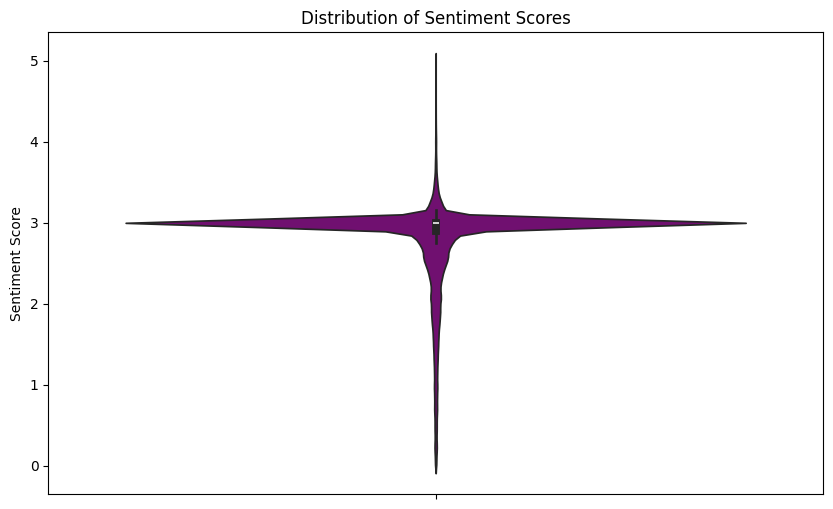

In [8]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=chair,
    y="Senti_n", 
    color="purple",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()

Observations (full dataset): 

Entire dataset:
- No. of all speeches:  311354
- Speeches of regular speakers:  153770 %:  49.38 (More than 50% of the dataset consists of procedural (Chairperson) speeches)
- Sentiment 3-class:  Senti_3
    - Neutral     61.702114
    - Negative    31.584627
    - Positive     6.711011
    - no sentiment: 0.002248

Chairperson speeches only: 
Distribution of the 3-class sent in procedural speeches:  Senti_3:
    - Neutral     95.376434
    - Negative     3.858894
    - Positive     0.764672


- The dataset consists of over 50% of chairperson speeches, which heavily dominates in the Neutral sentiment, which can directly impact the analysis results. Therefore, for the majority of the analysis, these speeches should be removed.

# Trend Analysis
### Removing procedural and Minister speeches, rechecking dataset characteristics

Given the fact that the procedural speeches (or, rather, speeches made by Chairperson) represent more than 50% of the dataset, this part of the dataset will be ommited from further analysis. 
Additionally, the Minister status can interfere with detection of trends, as Ministers serve or speak in line with their executive branch role, and are technically under the scrutiny of the Parliament or the legislative branch. Therefore, their speeches are not directly connected with a parliamentary group, though they can be affiliated with a political (intra-or-extra parliamentary group). Trends in both subsets were analysed separately and are detailed in the checks above. 


In [9]:
# Removing procedural speeches for the analysis, rechecking base characteristics
df = df[df["Speaker_role"] == "Regular"]
df = df[df["Senti_3"] != "-"]

print("No. of all speeches: ", len(df))
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts())


No. of all speeches:  153763
Earliest date:  2000-10-27
Latest date:  2022-04-06
No. of unique parties  26 ['SD' 'SLS' '-' 'NSi' 'PS' 'SDS' 'DL' 'DeSUS' 'NeP' 'IMNS' 'SMC' 'ZL'
 'ZaAB' 'NP' 'Levica' 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'DLGV' 'Lipa' 'Zares'
 'LDS' 'ZLSD' 'SLS+SKD' 'SMS']
Sentiment 6-class:  Senti_6
Negative            64805
Mixed Negative      27454
Neutral Negative    21751
Neutral Positive    20063
Mixed Positive      14752
Positive             4938
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Negative    92259
Neutral     41814
Positive    19690
Name: count, dtype: int64


### Minister distributions 

In [10]:
counts = df['Speaker_minister'].value_counts()
percentages = counts / counts.sum() * 100

percentages

Speaker_minister
notMinister    89.886384
Minister       10.113616
Name: count, dtype: float64

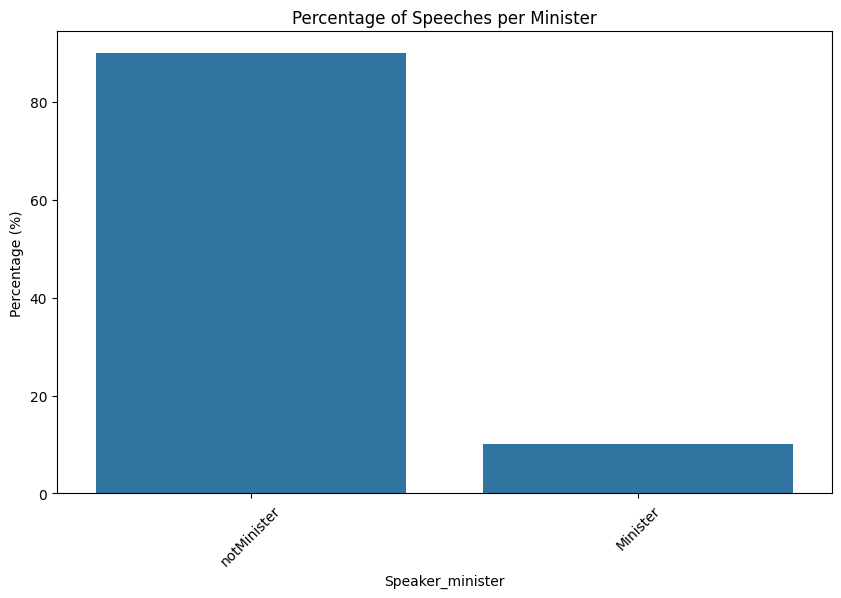

In [11]:
plot_df = percentages.reset_index()
plot_df.columns = ['Speaker_minister', 'Percentage']

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Speaker_minister', y='Percentage')
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.title("Percentage of Speeches per Minister")
plt.show()

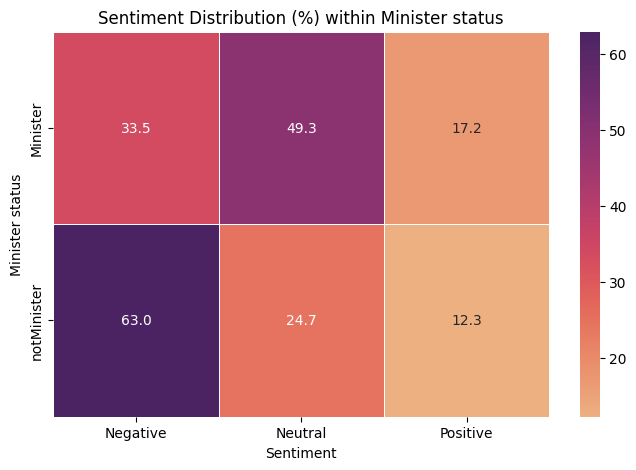

In [12]:
# Minister status x Sentiment categories 
mode = "row"
senti_version = 3

sent6_order = ["Negative", "Mixed Negative", "Neutral Negative", "Neutral Positive", "Mixed Positive", "Positive"]
sent3_order = ["Negative", "Neutral", "Positive"]


if senti_version == 3:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)
elif senti_version == 6:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)

else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within Minister status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Minister status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Minister status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Minister status")
plt.xlabel("Sentiment")
plt.show()



Minister x sentiment categories heatmap

Note: The speeches per Minister status are very unbalanced: 89% of nonMinister speeches, only 10% of Minister speeches.

3-class sentiment categories
- raw: notMinister/Negative combination seems to be the strongest, followed by notMinister/Neutral. For Ministers, the combination with most counts is Neutral sentiment, followed by Negative. 
- row: The trends from raw counts are preserved in the proportional distribution, with Minister/Neutral combination representing almost 50%, while the nonMinister/Negative remain the strongest trend with 63%. (This calculation mitigates the huge imbalance between the both observations, shows the proportional distributions more closely).
- col: In terms of how much does each Minister status contribute to the overall sentiment category, the notMinister speeches contribute the majority of speeches to each of the sentiment category (Negative: 94.4%, Neutral:81.7%, Positive:86.4%). This is also due to the imbalance between the sizes of the notMinister/Minster speeches
- global: In line with the aforementioned imbalance, when comparing the overall share of the dataset, the notMinister/Negative combination accounts for more than 50% of the dataset

6-class sentiment categories:
- The trends persist in the 6-class sentiment distributions, with "row" calculations showing the more realistic distribution between the observations (nonMinister/Minister), mitigating the Minister status data imbalance.
- raw count/row (contribution of each sentiment category in a Minister status category): notMinister: Negative: 45.1%, Mixed Negative: 17.9, ... 3.3% Positive. Minister: 27.3% Neutral negative, 22.0% Neutral Positive, ...2.4% Positive.
- col (contribution of speeches from each Minister status category in each Sentiment category): The same as for 3-class (majority, cca. 80-96% of speeches in each sentiment category are notMinister speeches), showcases data imbalance.
- global (overall share): As with 3-class sentiment, combination nonMinister/Negative represent 40,5% of the entire dataset (3-class: more than 50%), making Negative sentiment most representative for nonMinister speeches even on a more detailed sentiment scale. Data imbalance is also very visible in this calculation.

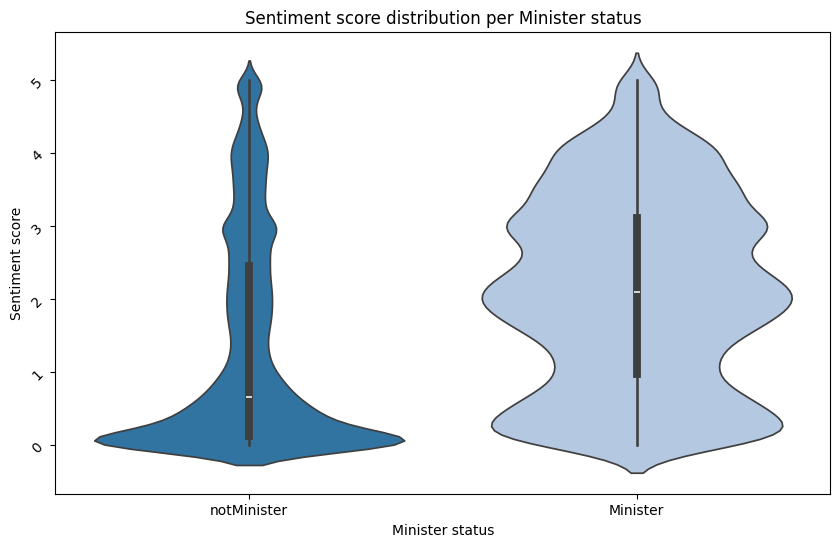

In [13]:
#Minister status x Sentiment score distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Speaker_minister", 
    y="Senti_n",
    hue="Speaker_minister",
    palette="tab20"
)

plt.title("Sentiment score distribution per Minister status")
plt.xlabel("Minister status"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

In [14]:
df.groupby("Speaker_minister")["Senti_n"].median()

Speaker_minister
Minister       2.10
notMinister    0.66
Name: Senti_n, dtype: float64

Speeches, made by Minister speakers represent around 10 % of the dataset with the ommited procedural speech. Additionally, the sentiment scores per Minister status show that the speeches made by Ministers tend to vary intensly in terms of sentiment (median= 2.10), while on the other hand, notMinister speakers tend to speak much more Negative (0.66). Given their role in the parliamentary procedures, and that the rest of the analysis will heavily focus on the parliamentary groups/political parties, the Minister speeches will also be omitted from the base dataset, to be used for all additional trend analysis.

## Party-level Overview
Inspecting speech and sentiment distributions across party-, status- and political orientation.

In [15]:
#Remove minister speeches from the dataset
df = df[df["Speaker_minister"] == "notMinister"]

In [16]:
# Table with overview of speeches, sentiment avg and sent percentages
#mapping = {"Far right":"FR", 
# "Right to far right": "R-FR", 
# "Centre-right":"CR", 
# "Centre to centre-left":"C-CR", 
# "Centre":"C", 
# "Centre to centre-left":"C-CL", 
# "Centre-left":"CL", 
# "Left":"L", 
# "Left to far left": "L-FL", 
# "Far left": "FL", 
# "-":"-", }

status = df.groupby(['Speaker_party','Party_status']).size().unstack(fill_value=0)
status.columns = ['Speech (U)', 'Speech (C)', 'Speech (O)']
avg_sent = df.groupby(['Speaker_party', 'Party_status'])["Senti_n"].mean().unstack(fill_value=0)
avg_sent.columns = ['Avg. Sent (U)', 'Avg. Sent (C)', 'Avg. Sent (O)']
sent_count = df.groupby(['Speaker_party', df['Senti_3']]).size().unstack(fill_value=0)
sent_percent = sent_count.div(sent_count.sum(axis=1), axis=0) * 100

party_metadata = df[['Speaker_party', 'Party_orientation']].drop_duplicates().set_index('Speaker_party')


overview = (
    status.merge(avg_sent, on="Speaker_party", how="left")
    .merge(sent_percent, on="Speaker_party", how="left")
    .merge(party_metadata, on="Speaker_party", how='left')
    .reset_index()
    )

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)


overview['Total Speeches'] = overview['Speech (U)'] + overview['Speech (C)'] + overview['Speech (O)']
total_speeches = overview['Total Speeches'].sum()
overview['Speech %'] = (overview['Total Speeches'] / total_speeches) * 100
overview = overview[['Speaker_party', 'Party_orientation', 'Total Speeches', 'Speech %', 'Speech (C)', 'Speech (O)','Speech (U)',
               'Avg. Sent (C)', 'Avg. Sent (O)','Avg. Sent (U)', '% Positive', '% Neutral', '% Negative']]

cols_to_format = [
    'Speech %', 'Avg. Sent (C)', 'Avg. Sent (O)', 'Avg. Sent (U)',
    '% Positive', '% Neutral', '% Negative'
]

for col in cols_to_format:
    overview[col] = overview[col].map(lambda x: f"{x:.1f}")

overview

,Speaker_party,Party_orientation,Total Speeches,Speech %,Speech (C),Speech (O),Speech (U),Avg. Sent (C),Avg. Sent (O),Avg. Sent (U),% Positive,% Neutral,% Negative
0,-,-,7250,5.2,0,0,7250,0.0,0.0,2.2,18.6,51.1,30.2
1,DL,Centre to centre-right,935,0.7,883,52,0,2.0,2.1,0.0,23.9,29.2,47.0
2,DLGV,Right,67,0.0,43,0,24,2.1,0.0,2.4,38.8,14.9,46.3
3,DeSUS,Centre to centre-left,6650,4.8,6469,181,0,2.1,2.6,0.0,27.9,28.2,43.9
4,IMNS,-,1036,0.7,0,0,1036,0.0,0.0,2.0,22.7,34.2,43.1
5,Konkretno,Centre,115,0.1,115,0,0,2.9,0.0,0.0,47.0,28.7,24.3
6,LDS,Centre to centre-left,13229,9.6,6814,6415,0,1.6,0.9,0.0,10.2,26.2,63.6
7,LMŠ,Centre to centre-left,2810,2.0,557,2213,40,1.8,0.8,2.2,8.4,18.5,73.1
8,Levica,Left,4802,3.5,0,4802,0,0.0,0.6,0.0,2.3,12.3,85.4
9,Lipa,-,395,0.3,0,0,395,0.0,0.0,0.8,4.1,19.0,77.0


## Party Activity
Investigation of party presence (and average sentiment) throughout the period, covered by the dataset. There are also several exceptions that need to be handled: 
- NeP = parliamentary group of independent MPs. As the NeP holds the same rights and has a formal status of parliamentary group, NeP remains in the analysis.
- NP = individual independent MPs, not connected into a parliamentary group. As we here focus on the parliamentary groups (or political parties), we omited NPs from the visualisation
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Included in the analysis

In [17]:
df["Month"] = df["Date"].str.split("-").str[:2].str.join("-")

#df_notMinister = df[df["Speaker_minister"]=="notMinister"] #Remove minister speaker, only interested into MP activity
activity = df.groupby(['Term', 'Parties']).agg( #Can also be checked by aggregated parties - "Parties"
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size'),
    Avg_sentiment=('Senti_n','mean')

).reset_index()
activity = activity[~activity['Parties'].isin(["-"])] #"NP", NeP
activity["Parties"].sort_values(ascending=True)

activity.head()

,Term,Parties,Start_date,End_date,Speech_count,Avg_sentiment
1,Term 3,DeSUS,2000-10-27,2004-10-07,666,2.168994
2,Term 3,IMNS,2000-11-16,2004-08-31,301,1.496811
3,Term 3,LDS,2000-10-27,2004-10-07,5355,1.542486
4,Term 3,NSi,2000-11-30,2004-10-07,4367,1.100183
5,Term 3,NeP,2002-01-22,2004-07-12,40,1.569500


In [18]:
import plotly.express as px
from PIL import Image

def plot_party_activity(df, mode="sentiment"):
    if mode=="activity":  ## Use for sample visualisation, for full dataset, use timeline
        fig = px.timeline(
            activity, 
            x_start="Start_date", 
            x_end="End_date",
            y="Parties", #Can be either Speaker_party for full range of individual parties, or Grouped_parties to emphasise changes in the lifespan of parties 
            color="Speech_count", 
            title="Party activity Across Terms (Speech count)", 
            labels={"Speech_count": "Speech Count"},
            color_continuous_scale="viridis"
        )
    elif mode=="sentiment":
        fig = px.timeline(
            activity,
            x_start="Start_date",
            x_end="End_date",
            y="Parties",
            color="Avg_sentiment",
            title="Party Activity Across Terms (Average sentiment)",
            labels={"Avg_sentiment": "Sentiment (mean)"},
        )
    else:
        raise ValueError("mode must be one of: activity, sentiment")
    fig.update_layout(
        height=600,  
        width=950,
        yaxis_title="Parties",
        xaxis_title="")
    return fig

#fig.write_image("path.png")


fig = plot_party_activity(activity, mode="sentiment")
fig.show()

## Sentiment trends (across party, political orientations, statuses...)

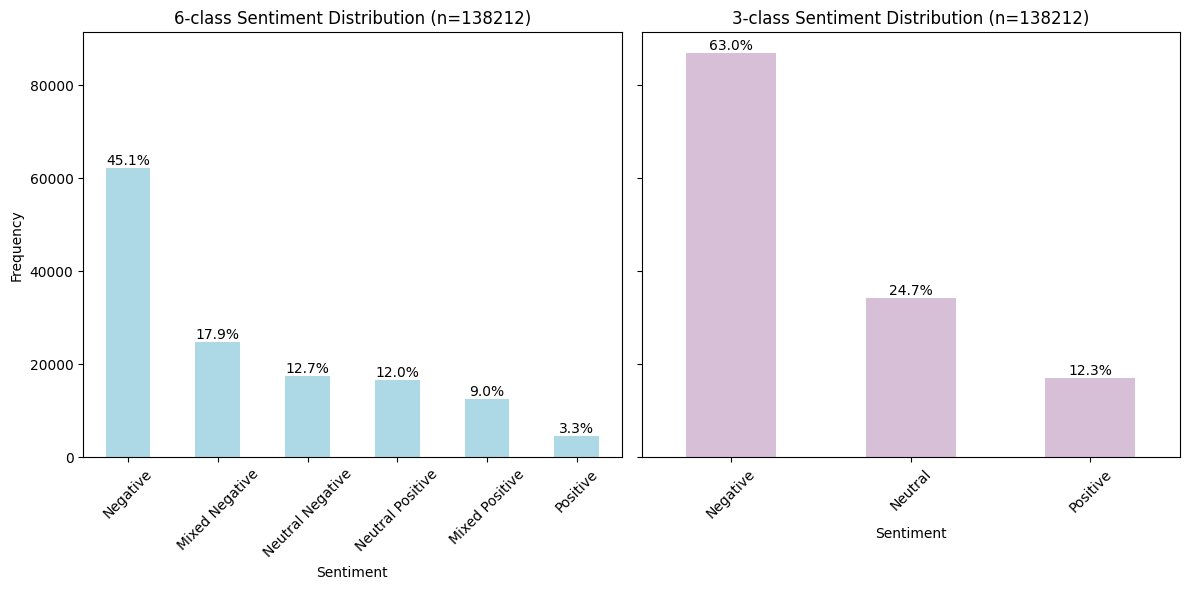

In [19]:
#General sentiment distribution in the corpus
df_sent6 = df["Senti_6"].value_counts()
df_sent3 = df["Senti_3"].value_counts()

def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_sent6.plot(kind='bar', ax=axes[0], color = 'lightblue')
axes[0].set_title(f'6-class Sentiment Distribution (n={len(df)})')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_sent6)

df_sent3.plot(kind='bar', ax=axes[1], color='thistle')
axes[1].set_title(f'3-class Sentiment Distribution (n={len(df)})')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sent3)

plt.tight_layout()
plt.show()

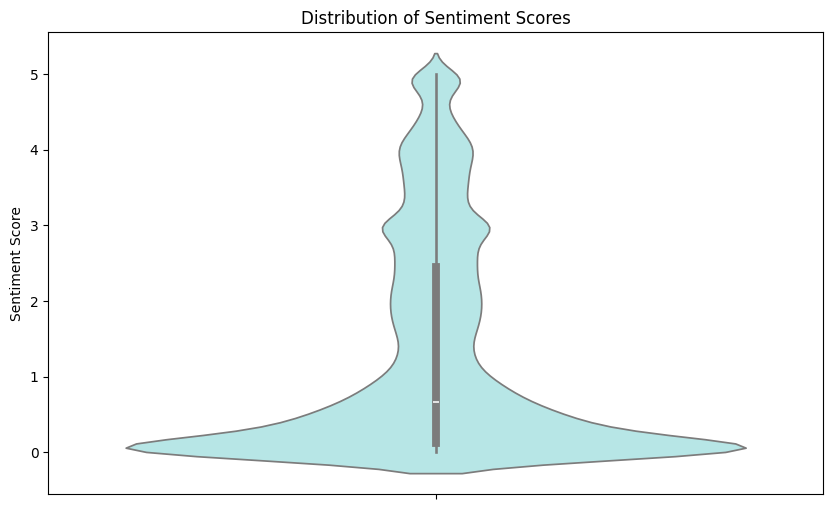

In [20]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    y="Senti_n", 
    color="paleturquoise",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()


In [39]:
print("Median sentiment value:", df["Senti_n"].median())
print("Mean sentiment:", df["Senti_n"].mean())

Median sentiment value: 0.66
Mean sentiment: 1.3486490319219748


The distribution of sentiment scores is skewed toward the negative end of the scale, with a very wide section around or slightly above 0, indicating a high concentration of negative sentiments, while the interquartile range (Q1–Q3) extends up to approximately 2.5. The median score of 0.66 suggests that overall sentiment tends to lean negative, though some observations reach more positive scores.

### Party status x Sentiment (categories, numerical scores)

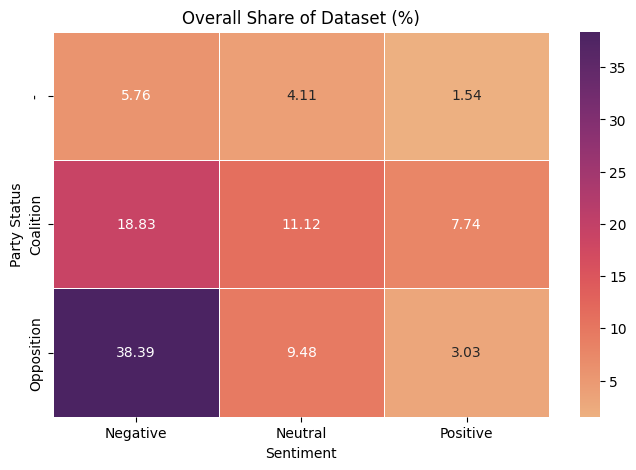

In [22]:
# Party status x Sentiment categories 
# Choose normalization mode: "row", "col", "global", or "none"

mode = "global"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)

else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Status")
plt.xlabel("Sentiment")
#plt.savefig("../Results/Figures/Status_heatmap_global.png")

plt.show()


In [23]:
df["Party_status"].value_counts()

Party_status
Opposition    70346
Coalition     52093
-             15773
Name: count, dtype: int64

Sentiment categories per Party status (coalition/opposition), trends:
- Size differences: Opposition - 70346 speeches, Coalition - 52093 speeches, no status: 15773 -> Coalition and Opposition speeches are relatively well distributed, with not too big of a difference.

3-class sentiment: 
- Raw counts: The raw count without a doubt show a major difference between Coalition and Opposition in the amount of Negative sentiment, the strongest distribution being Negative/Opposition combination (53061), followed by Coalition/Negative (26022). 
- Row % calculations (Sentiment distribution (%) within each Party status): Trend of distinctly higher percentage of Negative sentiment within each sentiment category:
    - (Opposition-Negative: 75.4%, Opposition-Neutral: 18.6%, Opposition-Positive - 5.9% 
    - Coalition-Negative: 50.0%, Coalition-Neutral:29.5, Coalition-Positive: 20.5
    - No status-Negative: 50.5 / No Status-Neutral:36.0%, No Status-Positive: 13.5%). 
    - Relatively high percentage (compared to other Positive-wise trends) of Positive sentiment speeches within Coalition.
- Col % calculations (Status Contributions (%) within each Sentiment): Two very noticable trends - high % of Opposition speeches in Negative (trends persist) + high percentage of Coalition speeches within Positive sentiment (even higher than for Oposition-Negative).
- Global (Overall Share of Dataset (%)): Unsurprisingly, the trend of Opposition/Negative persists (38.39%), followed by combination Coaltion/Negative (18.83). The lowest share of the dataset is represented in the combination "-" (no status/guest speakers)/Positive (1.54).
6-class sentiment:
- Raw counts: Strong trend of Opposition-Negative (40799), Negative is also the sentiment most present in each of the status categories.
- Row (Sentiment distribution (%) within each Party status): Same trends as with raw counts
- Col (Status Contributions (%) within each Sentiment): Most speeches in the Negative sentiment were contributed by the Opposition, while the largest share of speeches in the Positive sentiment were contributed by Coalition. Additionally, Coalition speeches were also very present in the Mixed Positive category (60.8%), while Opposition speeches represent still a relatively large share inthe Mixed Negative sentiment category (preserving the overarching trends from the 3-level sentiment).
- Global: When checking the shares of Sentiment/Status, the combination of Opposition/Negative represents the largest share of the dataset (29.52%), followed closely by Coalition/Negative combination, while the lowest share of dataset is represented by the "-"/Positive combination, followed closely by Opposition/Positive, which reflects similar trend to the one detected in the 3-class sentiment x status heatmap. 

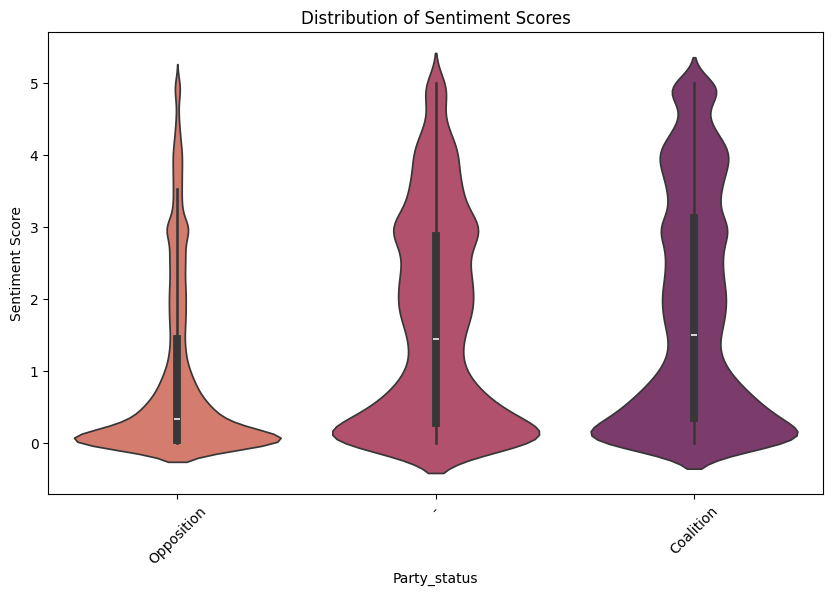

In [24]:
#Party status x sentiment score distribution

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_status",
    y="Senti_n", 
    hue="Party_status",
    palette="flare",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xlabel("Party_status")
plt.xticks(rotation=45)
plt.show()

In [25]:
df.groupby("Party_status")["Senti_n"].median()

Party_status
-             1.45
Coalition     1.50
Opposition    0.33
Name: Senti_n, dtype: float64

The violin plot illustrates the distribution of numerical sentiment scores across different party statuses. Similar to the patterns observed in the heatmap above, Opposition speeches are predominantly centered around negative sentiment values (median = 0.33). In contrast, both Coalition and non-affiliated (“–”) speakers show a more balanced spread of sentiment scores, though the Coalition still leans somewhat negative (medians: “–” = 1.45, Coalition = 1.50).

In [26]:
#Party status x average sentiment score (across years)
# Plot sample trends per "Month", use "Year" for better full dataset visualisations

status_term = df.groupby(["Party_status", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term
fig=px.line(status_term, x="Year", y="Senti_n", color="Party_status", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Party',
    template='plotly_white'
)
fig.show()


Avg. Sentiment x Status per Year: 
- Consistent difference between average sentiment scores of Coalition and Opposition speeches. 
- Guest speakers ("-") fluctuate (especially the first half of the period covered)
- Sharp positive jump in Coalition speeches in 2021-2022 (14th Government)
- Sharp dive in sentiment for guest speakers in 2008

### Political orientation x Sentiment (categories, scores)

In [27]:
# Political orientation x Sentiment categories 
mode = "global"
senti_version = 3

order = ["-", "Left", "Centre-left", "Centre to centre-left", "Centre", "Centre to centre-right", "Centre-right", "Right", "Right to far-right"]

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)

elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)

else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party Orientation category"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Orientation Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Orientation"


data 



Senti_3,Negative,Neutral,Positive
Party_orientation,,,
-,3.455561,3.291321,1.350100
Centre,0.020259,0.023876,0.039070
Centre to centre-left,13.169623,6.087026,3.737013
Centre to centre-right,0.317628,0.197523,0.161346
Centre-left,10.935375,4.374439,2.361589
Centre-right,8.568721,3.939600,2.360142
Left,4.489480,0.623680,0.122276
Right,17.869650,4.964113,1.823286
Right to far-right,4.154487,1.204671,0.358145


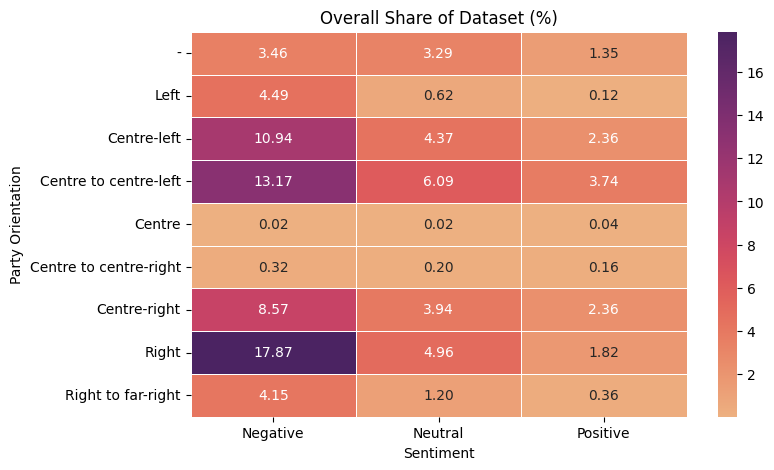

In [28]:
plt.figure(figsize=(8, 5))
data = data.reindex(order)
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()

Sentiment Categories x Party Orientation heatmap

3-class sentiment:
- Raw counts: 
    - Right/Negative (24698), followed closely by Centre to centre-left/Negative (18202) and Centre to centre-left (15114).
    - Centre/Negative (28) seems to be the other end of the spectrum. 
    - High difference in the speech count/sentiment distribution for Left orientation (6205 - Negative, 862-Neutral, 169-Positive)
- Row (Sentiment distribution (%) within each Party orientation):
    - Very clear that most orientations have the largest share of their speeches in the Negative category (with the exception of Centre, where largest share (47.0%) seems to be Positive).
    - The difference in speeches from raw counts for Left is seen clearly in this visualisation (Left: 85.8% Negative, 11.9% Neutral, 2.3% Positive), which is also the largest share of Negative speeches in any of the orientations (and the lowest share of Positive speeches in the any Orientations category). 
    - The largest share of Neutral sentiment is seen in guest speeches ("-", 40,6%), most other are distributed around 20-30% for each orientation (with the exception of Left with 11.9%)
- Col (Orientation Contributions (%) within each Sentiment):
    - Two most notable trends are the highest percentege of Right speeches in Negative sentiment (28.4) and Centre to centre-left speeches in Positive sentiment category (30.4), while the largest share in the Neutral category come from Centre to centre-left speeches (24.6). 
    - Centre and Centre to centre right orientation contribute really small percentages of speeches in either Negative, Neutral or Positive category
- Global (% of Overall Dataset)
    - The speeches by Right Orientation in Negative sentiment seem to represent the higest percentage of the overall dataset (17.87%). Additionally, the shares are relatively small (dataset is quite fragmented). Followed closely are also shared of Centre to centre-left (13.17%) speeches and Centre-left (10.94%) speeches with Negative sentiment. 
    - The Left speeches, which had very strong presence in Negative sentiment for raw counts and row visualisation, now only represent 4.49% of the overall dataset. It is important to note the difference in overall party presence (and its orientation) in the period/Parliament covered (seen in the table and timeline Party activy).

6-class sentiment: 
-  Raw counts: 
    - Similar trends detected as for 3-class sentiment, just with different raw counts. In addition, there also a relatively high difference/fragmentation present in the Right speeches (18973 Negative, 5737 Mixed Negative, 3487 Mixed Neutral, 3374 Neutral Positive, 1877 Mixed Positive, 643 Positive)
- Row: Similar to trends regarding Negative sentiment in orientations as in 3-class sentiment, with an exceptions: Centre, where the majority of the speeches come from Mixed Positive (Centre - 29.6%).
- Cols: The trends in 6-class follow trends from 3-class trends. The most notable distinction is the consistent 15-18% and 20-30% share of Centre-left and Centre to centre-left speeches amongst all of the 6-class sentiment categories.
- Global: Similar trends than in 3-class: Highest share Right/Negative (13.73), high fragmentation.

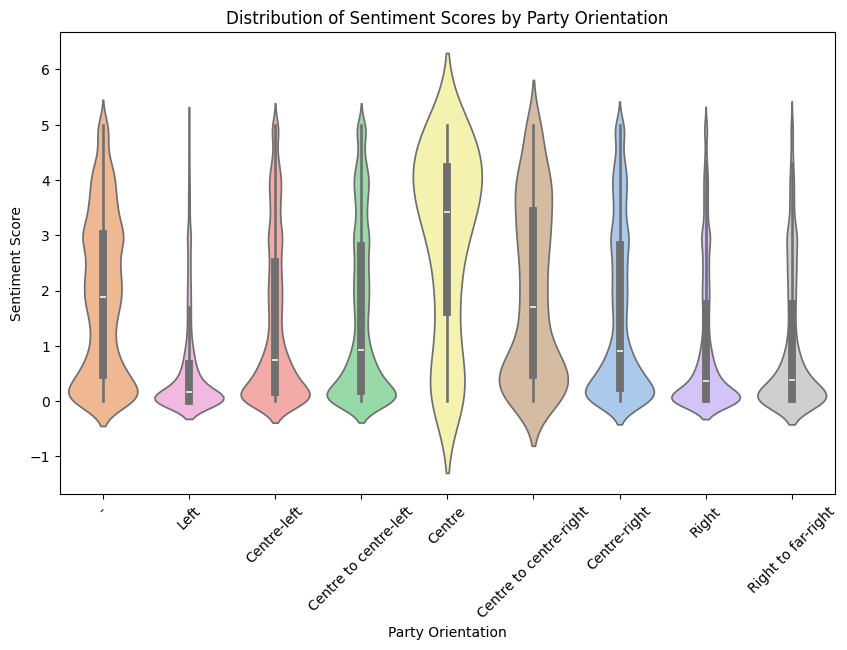

In [29]:
#Political orientation x sentiment scores (distributions)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_orientation", 
    y="Senti_n", 
    hue="Party_orientation", 
    palette="pastel",
    order=order,
)
plt.title("Distribution of Sentiment Scores by Party Orientation")
plt.xlabel("Party Orientation")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


In [30]:
df.groupby("Party_orientation")["Senti_n"].median()

Party_orientation
-                         1.88
Centre                    3.42
Centre to centre-left     0.92
Centre to centre-right    1.70
Centre-left               0.75
Centre-right              0.90
Left                      0.16
Right                     0.37
Right to far-right        0.38
Name: Senti_n, dtype: float64

Distribution of Sentiment scores by Party Orientation
The Left, Right and Right to far-right orientations gravitate heavily towards Negative sentiment (Median: Left - 0.16, Right to far-right - 0.38, Right - 0.37, ), while the Guest speakers (no orientation, "-") and Centre have much more distributed values, and higher medians ("-": 1.88, Centre: 3.42 - which is also the higest median amongst Orientation categories).

In [31]:
#Political orientation x Sentiment scores (across years)
# Plot sample trends per "Month", use "Year" for better full dataset visualisations


status_term = df.groupby(["Party_orientation", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Year", y="Senti_n", color="Party_orientation", category_orders={"Party_orientation":["-", "Left", "Centre-left", "Centre to centre-left", "Centre", "Centre to centre-right", "Centre-right", "Right", "Right to far-right"]}, markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white',
)


fig.show()


- Several very distinct changes in sentiment trends: 
    - 2020 - end of period:  Very distinct trend of centre, right-oriented parties (Centre, Centre-right, Right, Right to far right) and guest speakers picking up in the beginning of 2020 (change of Government) while the left-pole parties/orientations fall in sentiment (Left, Centre-left, Centre to centre-left).
    - 2012 - 2013: Centre to centre-left, Centre-left up; Right, Centre-right sharp down, "-" stable
    - 2011 - 2012: Centre to centre-left, Centre-left down; Right, Centre-right sharp up, "-" stable
    - 2008 - 2011: Centre to centre-left, Centre-left up; Centre-right, Right, guest down
    - 2004 - 2008: Right, Centre-right, guest up; Centre-left, Centre to centre-left, Right to far-right down; 
- Reason: changes in Government (2012, 2013) and/or Term change (2004, 2008)

### Parliamentary groups/Political parties x Sentiment

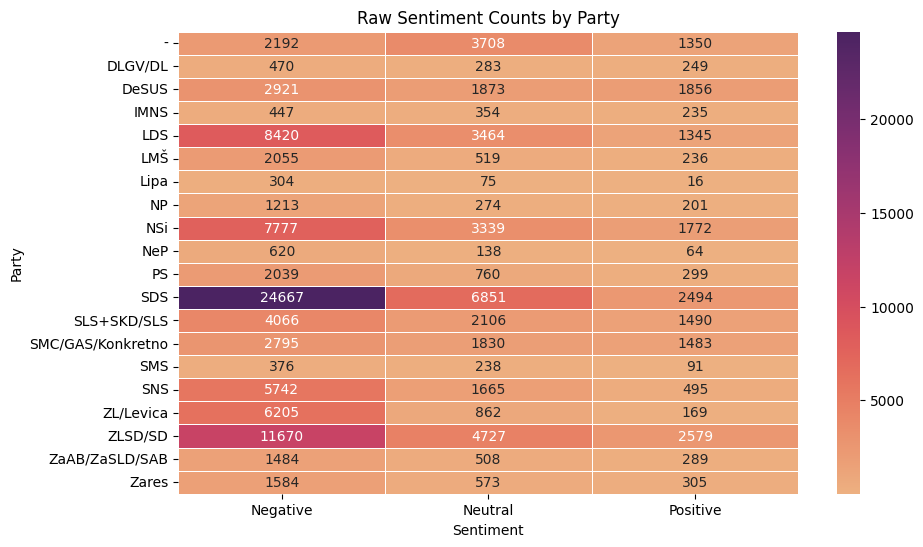

In [32]:
# Political party x Sentiment categories 
mode = "raw"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Parties'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)

elif senti_version == 6:
    crosstab = pd.crosstab(df['Parties'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Party Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party"

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party")
plt.xlabel("Sentiment")
plt.show()


Sentiment categories by Parliamentary group/Party

6-class sentiment:
- Raw counts: the SDS/Negative (18956) combination has the higest overall count, followed by (with a large difference in count) ZLSD/SD (7809). The stronger trends in raw count pertain to (mostly) Negative sentiment category.
- Row: The trends in the raw counts can also be seen in the sentiment distribution within each Party, where most parties have the highest share of their speeches in Negative sentiment (ranging from 25 - 69%). This does not hold true for the Guest speakers (where the highest shares, 25.9 and 25.3% of speeches belong to the Neutral Positive and Neutral Positive).
- Col: SDS (being the party with highest speech share in the overall dataset) contributes (mostly) the highest share of their speeches in each sentiment category (with the exception of the Mixed Positive and Positive category, where in both categories the largest share comes from ZLSD/SD party). It is important to note that both both parties are large, very vocal and have been present for the entire period under observation (SDS - 24% , ZLSD/SD - 12,7% of the entire dataset). 
- Global: SDS/Negative combination represents the highest share in the overall dataset (13.72%),  followed by ZLSD/SD/Negative (5.65%). Given the share of the overall dataset both parties represent, this is not that surprising. 

3-class sentiment: Trends detected in 6-class sentiment analysis can be seen also in the 3-class sentiment
Raw:
- SDS/Negative dominates the count: 24667, followed by ZLSD/SD: 11670
- largest share of speeches (for all parties but Guest speakers) seem to be in Negative sentiment
Row: 
- Ditto, shares range from (45 - 85%) of speeches by individual party in Negative category.
Col: 
- Same as in 6-class sentiment: SDS contributes largest share of speeches to individual Category (size imbalance), followed by ZLSD/SD.
Global: 
- Same as in 6-class, dataset imbalance (SDS and ZLSD/SD, largest share)

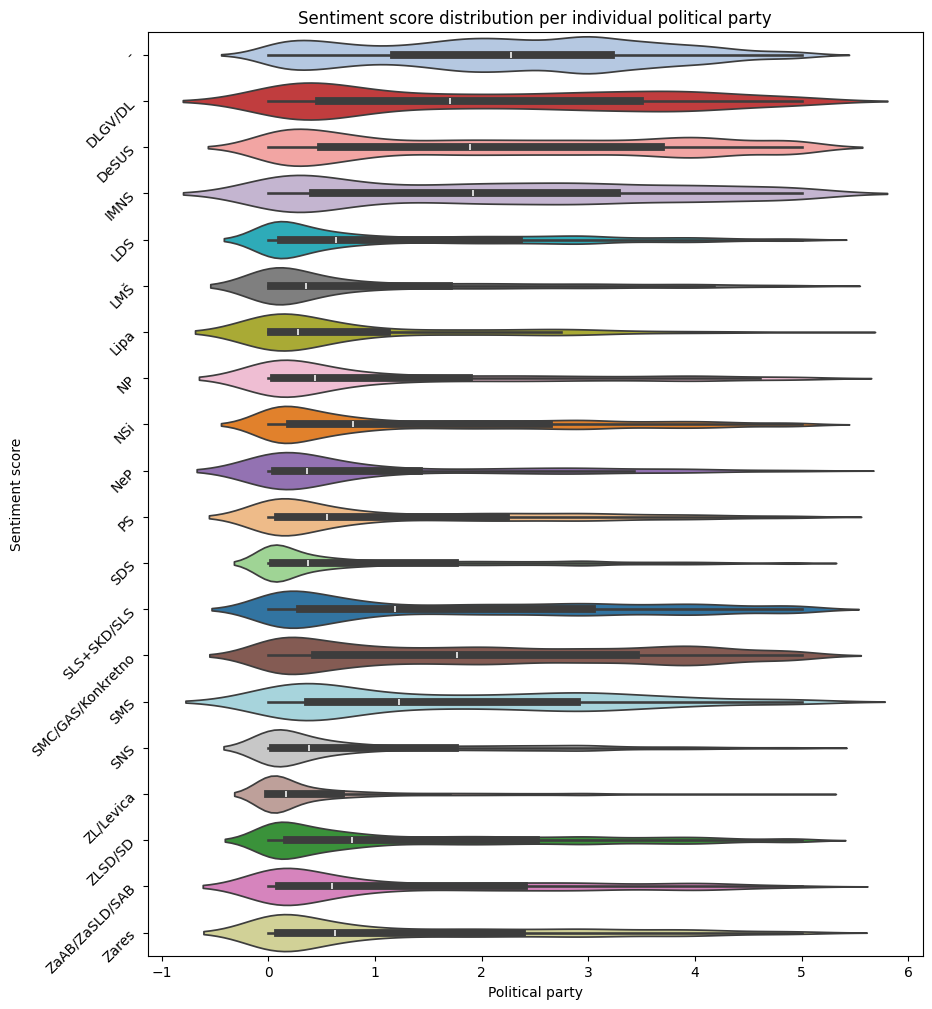

In [33]:
#Parliamentary groups x Sentiment score distributions
party_order = sorted(df["Parties"].unique())
plt.figure(figsize=(10, 12))
sns.violinplot(
    data=df,
    x="Senti_n", 
    y="Parties",
    hue="Parties",
    palette="tab20",
    order=party_order
)

plt.title("Sentiment score distribution per individual political party")
plt.xlabel("Political party"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

In [34]:
df.groupby("Parties")["Senti_n"].median().sort_values()

Parties
ZL/Levica            0.160
Lipa                 0.280
LMŠ                  0.350
NeP                  0.360
SDS                  0.370
SNS                  0.380
NP                   0.440
PS                   0.550
ZaAB/ZaSLD/SAB       0.600
Zares                0.620
LDS                  0.630
ZLSD/SD              0.780
NSi                  0.790
SLS+SKD/SLS          1.190
SMS                  1.220
DLGV/DL              1.705
SMC/GAS/Konkretno    1.770
DeSUS                1.890
IMNS                 1.920
-                    2.270
Name: Senti_n, dtype: float64

Sentiment score distribution by party
Most of the parties lean heavily towards negative speeches, with very low median. The lowest median belongs to speeches in ZL/Levica (0.16), followed by Lipa (0.28) and LMŠ (0.35), close also to NeP, SDS and SNS (0.36 - 0.38). The Guest, SMC/GAS/Konkretno, DLGV/DL, DeSUS, and IMNS speeches seem to a bit more diverse in terms of sentiment (as seen with a longer interquartile range), as well as having higer medians (DLGV/DL. 1.7, SMC/GAS/Konkretno: 1.7, DeSUS: 1.8, Guest: 2.2), though these are not all that high overall.

In [35]:

party_sent = df.groupby(["Year", "Parties"])["Senti_n"].mean().reset_index()
#party_sent = party_sent.sort_values(by="Term")
party_sent["Senti_n"] = pd.to_numeric(party_sent["Senti_n"])
party_sent.head(10)



,Year,Parties,Senti_n
0,2000,-,2.240000
1,2000,DeSUS,2.423636
2,2000,IMNS,2.252500
3,2000,LDS,2.080714
4,2000,NSi,0.997778
5,2000,SDS,0.942553
6,2000,SLS+SKD/SLS,2.246923
7,2000,SMS,2.617273
8,2000,SNS,1.443636
9,2000,ZLSD/SD,2.550714


In [36]:
fig=px.line(party_sent, x="Year", y="Senti_n", color="Parties", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=850,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white',
)

fig.show()

The visualisation allows for an in-depth exploration of individual party trends, where several points can be seen:
- There are distinct changes in sentiment for the years 2004, 2008, 2011, 2012, 2020
- This is most ditinctly seen when comparing SDS and ZLSD/SD trends, where the parties are always in opposition to each other
- Clearer investigation of trends can be seen in the next and final visualisation.

In [37]:
trends = party_sent[party_sent['Parties'].isin(['ZLSD/SD', 'SDS'])]
trends.head()

,Year,Parties,Senti_n
5,2000,SDS,0.942553
9,2000,ZLSD/SD,2.550714
15,2001,SDS,1.079770
19,2001,ZLSD/SD,1.892000
26,2002,SDS,1.036227


In [38]:
fig=px.line(trends, x="Year", y="Senti_n", color="Parties", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=850,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white',
)

fig.show()

Visualisation of only ZLSD/SD and SDS trends in average sentiment, which directly shows the previously mentioned point of how sentiment changes correspond to their changes in roles within the Parliament. 
